Saving front.jpg to front (7).jpg
Saving left.jpg to left (7).jpg
Saving right.jpg to right (7).jpg

0: 448x640 2 cars, 1 traffic light, 107.6ms
Speed: 2.6ms preprocess, 107.6ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)


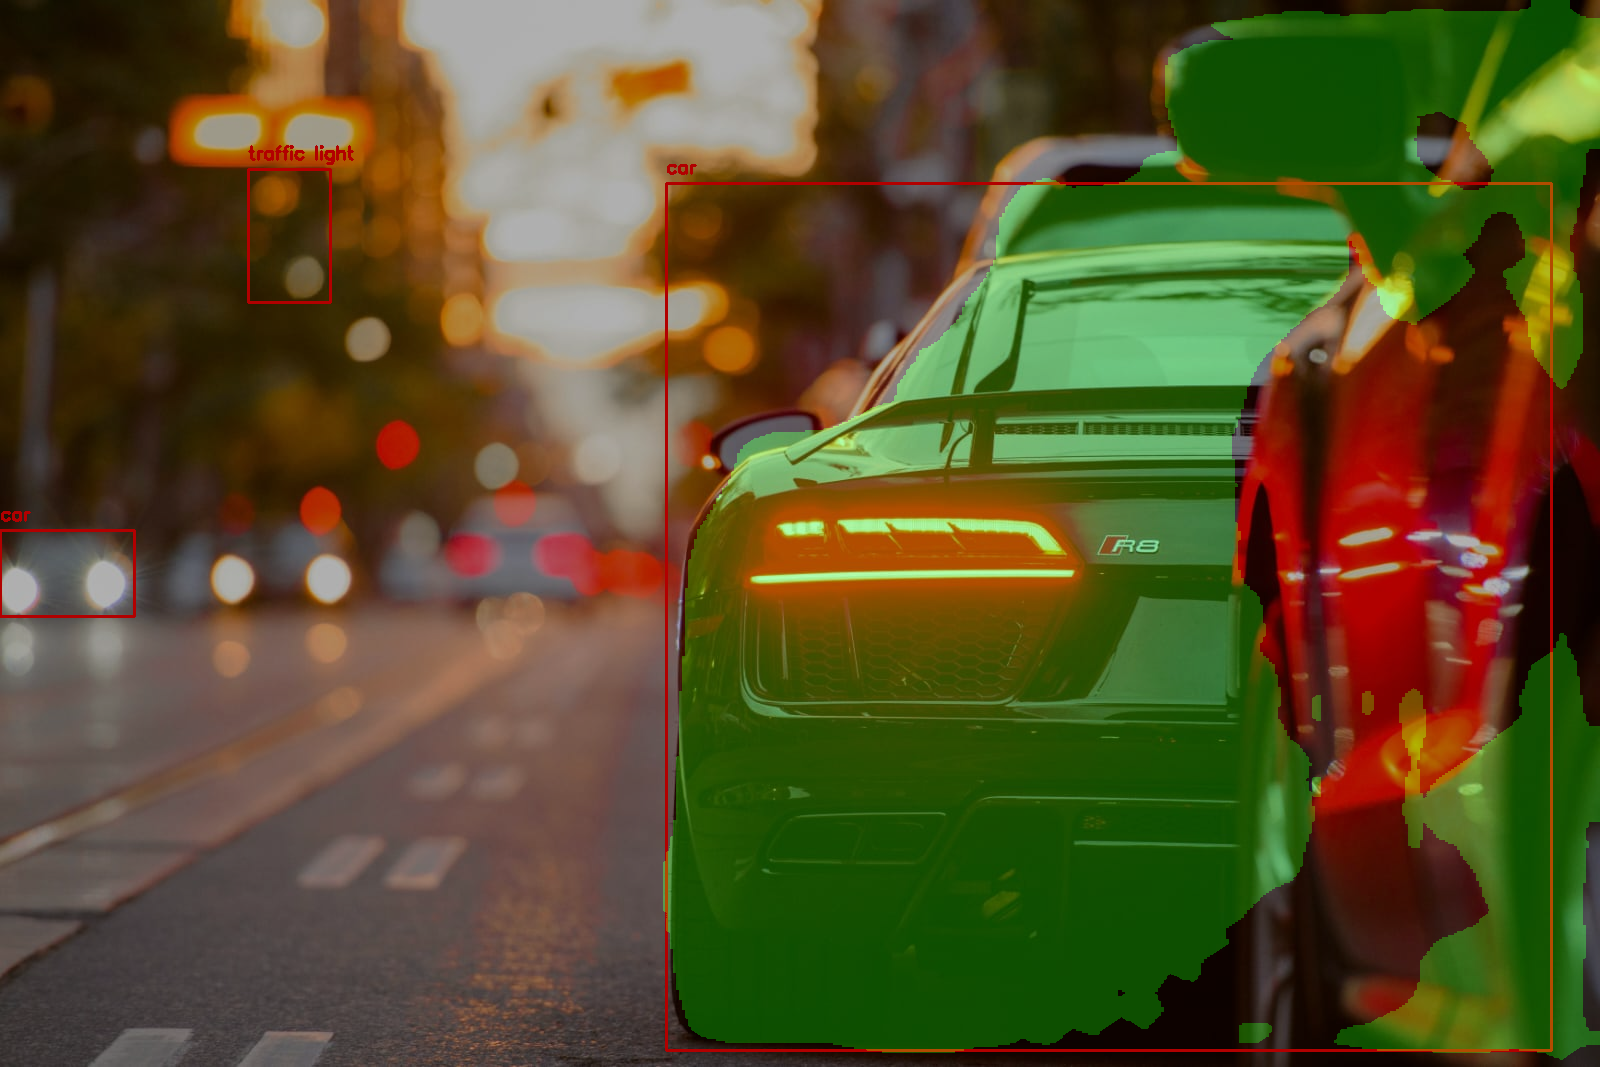

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
#python code for YOLO+DeepLabV3+
# Install YOLO
!pip install ultralytics
# Install required libraries
!pip install torch torchvision matplotlib pillow
#upload images(front.jpg, left.jpg,right.jpg are provided to upload in the image folder in appendix)
from google.colab import files
files.upload()

import cv2
from google.colab.patches import cv2_imshow

from ultralytics import YOLO
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet50
import cv2
import numpy as np

# Load models
yolo = YOLO("yolov8n.pt")
deeplab = deeplabv3_resnet50(weights="DEFAULT")
deeplab.eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520,520)),
    T.ToTensor(),
])

image = cv2.imread("front.jpg")
orig = image.copy()

# YOLO detection
results = yolo(image)[0]
for box in results.boxes:
    x1,y1,x2,y2 = map(int, box.xyxy[0])
    label = yolo.names[int(box.cls[0])]
    cv2.rectangle(image,(x1,y1),(x2,y2),(0,0,255),2)
    cv2.putText(image,label,(x1,y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,0,255),2)

# DeepLab segmentation
tensor = transform(orig).unsqueeze(0)
with torch.no_grad():
    output = deeplab(tensor)["out"][0]

mask = output.argmax(0).byte().cpu().numpy()
mask = cv2.resize(mask,(orig.shape[1],orig.shape[0]))

colored = np.zeros_like(orig)
colored[mask > 0] = [0,255,0]

# Fusion
fused = cv2.addWeighted(image,0.7,colored,0.3,0)

cv2_imshow(fused)
cv2.imwrite("object+pixel.jpg", fused)
files.download("object+pixel.jpg")
cv2.waitKey(0)
cv2.destroyAllWindows()